# Business Understanding
Many industries need to automatically identify objects in images, such as products, vehicles, or animals. Manual image classification is slow and expensive, so deep learning models help improve speed, accuracy, and efficiency. In this project, the CIFAR-10 dataset is used to build and compare ANN and CNN models to understand which approach performs better for image classification tasks.
# Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

# 1. Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 2. Load the Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3652s 21us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 3. Data Preprocessing

This step normalizes the pixel values from 0-255 to 0-1 by dividing by 255, which helps the model train faster and more effectively. The images are then flattened from 32 × 32 × 3 into a 1D vector of 3072 features so they can be used as input for the ANN model.

In [3]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

## 4. Baseline ANN Model

This is the baseline Artificial Neural Network (ANN) model used for image classification on the CIFAR-10 dataset. It consists of fully connected layers with ReLU activation and a Dropout layer to reduce overfitting. The model is trained to establish a baseline performance before comparing it with the CNN model.

In [4]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1783864501.378324      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/10
 66/704 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1462 - loss: 2.5815

I0000 00:00:1783864506.372793     151 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2713 - loss: 1.9941 - val_accuracy: 0.3456 - val_loss: 1.8370
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3166 - loss: 1.8702 - val_accuracy: 0.3650 - val_loss: 1.7832
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3373 - loss: 1.8205 - val_accuracy: 0.3876 - val_loss: 1.7499
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3442 - loss: 1.7951 - val_accuracy: 0.3912 - val_loss: 1.7188
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3597 - loss: 1.7669 - val_accuracy: 0.4028 - val_loss: 1.7153
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3597 - loss: 1.7564 - val_accuracy: 0.3878 - val_loss: 1.7124
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3691 - loss: 1.7369 - val_accuracy: 0.4054 - val_loss: 1.7082
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3740 - loss: 1.7192 - val_accuracy: 0.4088 - val_

In [5]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4271 - loss: 1.6453
ANN Test Accuracy: 0.4271000027656555


**Observation:** 
- The ANN model achieved 42.71% test accuracy on the CIFAR-10 dataset.
- The model improved with each epoch, and the loss decreased during training.
- It learned the images, but the accuracy is not very high because ANN is not well suited for image classification.
- This result will be compared with the CNN model to see which performs better.

## 5. CNN (baseline model)
- In this step, a Convolutional Neural Network (CNN) is built for image classification. 
- It uses Convolutional layers to extract image features
- Batch Normalization to improve training stability
- Max Pooling to reduce image size, and Dropout to reduce overfitting. 
- The model is trained using the Adam optimizer for 10 epochs with a batch size of 64, while 10% of the training data is used for validation.

In [6]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4742 - loss: 1.4828 - val_accuracy: 0.5628 - val_loss: 1.2336
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6104 - loss: 1.1157 - val_accuracy: 0.6260 - val_loss: 1.0590
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6702 - loss: 0.9433 - val_accuracy: 0.6398 - val_loss: 1.0657
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7104 - loss: 0.8260 - val_accuracy: 0.6846 - val_loss: 0.9197
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7428 - loss: 0.7347 - val_accuracy: 0.6994 - val_loss: 0.8497
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7692 - loss: 0.6541 - val_accuracy: 0.7128 - val_loss: 0.8936
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7898 - loss: 0.5930 - val_accuracy: 0.5562 - val_loss: 1.4211
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8115 - loss: 0.5329 - val_accuracy: 

In [7]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7028 - loss: 1.0221
CNN Test Accuracy: 0.7027999758720398


**Observation:** 
- The CNN model achieved 70.27% test accuracy on the CIFAR-10 dataset.
- The training accuracy improved in every epoch, showing that the model learned the image features well.
- The CNN performed better than the ANN model because it can capture important patterns and features from images.
- This shows that CNN is more suitable for image classification tasks than ANN.

## 6. Comparison of Model Validation Accuracy

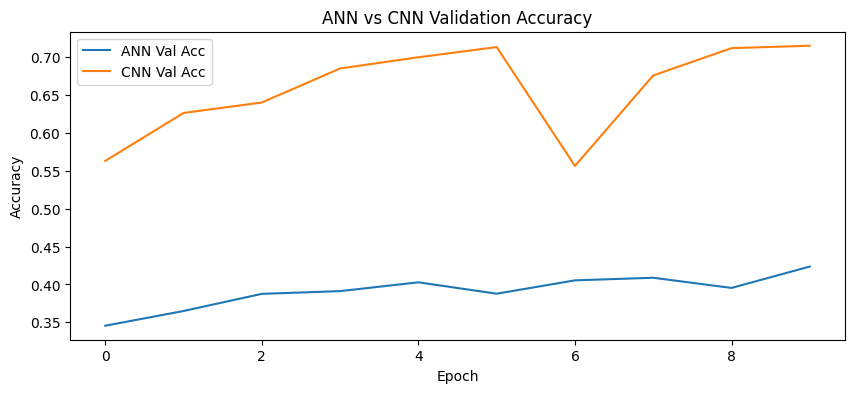

In [8]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

**Observation**
- The CNN model achieved higher validation accuracy than the ANN model throughout all training epochs.
- The ANN model improved gradually but reached only about 41% validation accuracy.
- The CNN model reached around 74% validation accuracy, showing much better learning performance.
- Overall, the graph shows that CNN is more effective than ANN for image classification because it learns image features more efficiently.

# 7. Improved ANN Model (Deeper Architecture)
- This step builds an improved ANN model by adding more hidden layers, Batch Normalization, and Dropout. 
- The deeper architecture helps the model learn more complex patterns
while batch normalization improves training stability and dropout reduces overfitting. 
- The model is trained for 10 epochs and then evaluated on the test dataset to compare its performance with the baseline ANN and CNN models.

In [9]:
ann_deep_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_deep_history = ann_deep_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_deep_test_loss, ann_deep_test_acc = ann_deep_model.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", ann_deep_test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.3163 - loss: 1.9227 - val_accuracy: 0.3638 - val_loss: 1.7761
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3780 - loss: 1.7257 - val_accuracy: 0.3500 - val_loss: 1.8390
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4045 - loss: 1.6606 - val_accuracy: 0.4100 - val_loss: 1.6719
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4031 - loss: 1.6624 - val_accuracy: 0.3930 - val_loss: 1.6713
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4083 - loss: 1.6517 - val_accuracy: 0.4386 - val_loss: 1.6047
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4143 - loss: 1.6325 - val_accuracy: 0.4072 - val_loss: 1.6725
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4212 - loss: 1.6160 - val_accuracy: 0.4466 - val_loss: 1.5663
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4236 - loss: 1.6089 - val_accuracy: 0

**Observation:** 
- The improved ANN model achieved 45.33% test accuracy on the CIFAR-10 dataset.
- It performed better than the baseline ANN (42.71% accuracy).
- Adding more layers, Batch Normalization, and Dropout helped the model learn better and improved its performance.
- However, the CNN model still performed better, showing that CNN is more effective for image classification tasks.

## 8. Enhanced CNN Model with Data Augmentation and Early Stopping
- This step builds an enhanced CNN model by adding data augmentation, more convolutional layers, Batch Normalization, Global Average Pooling, Dropout, and Early Stopping. 
- Data augmentation creates different versions of training images to improve generalization
- Early Stopping stops training when the validation loss no longer improves, helping to prevent overfitting. 
- The model is trained for up to 20 epochs and evaluated on the test dataset.

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

enhanced_data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

enhanced_cnn_model = models.Sequential([
    enhanced_data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

enhanced_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

enhanced_cnn_history = enhanced_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_cb]
)

enhanced_cnn_test_loss, enhanced_cnn_test_acc = enhanced_cnn_model.evaluate(x_test_norm, y_test)
print("Enhanced CNN (filters+aug+20ep+EarlyStopping) Test Accuracy:", enhanced_cnn_test_acc)
print("Stopped at epoch:", len(enhanced_cnn_history.history['loss']))

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.4569 - loss: 1.5158 - val_accuracy: 0.5464 - val_loss: 1.2639
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5727 - loss: 1.2045 - val_accuracy: 0.5970 - val_loss: 1.1241
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6238 - loss: 1.0721 - val_accuracy: 0.6216 - val_loss: 1.1068
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6550 - loss: 0.9908 - val_accuracy: 0.4800 - val_loss: 1.7706
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6751 - loss: 0.9320 - val_accuracy: 0.6696 - val_loss: 0.9841
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6967 - loss: 0.8771 - val_accuracy: 0.6964 - val_loss: 0.8840
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7143 - loss: 0.8296 - val_accuracy: 0.6796 - val_loss: 0.9473
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7228 - loss: 0.8005 - val_acc

**Observation:** 
- The enhanced CNN model achieved 76.77% test accuracy on the CIFAR-10 dataset.
- It performed better than both the baseline CNN (70.27%) and the improved ANN (45.33%).
- Data augmentation, additional CNN layers, Batch Normalization, and Early Stopping helped improve the model's performance and reduce overfitting.


# 9. Comparison of Model Validation Accuracy

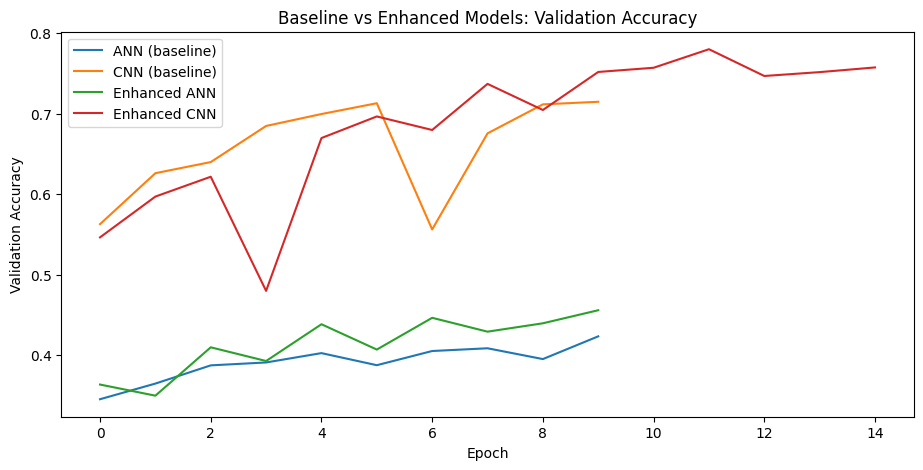

In [11]:
plt.figure(figsize=(11,5))
plt.plot(ann_history.history['val_accuracy'], label='ANN (baseline)')
plt.plot(cnn_history.history['val_accuracy'], label='CNN (baseline)')
plt.plot(ann_deep_history.history['val_accuracy'], label='Enhanced ANN')
plt.plot(enhanced_cnn_history.history['val_accuracy'], label='Enhanced CNN')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Baseline vs Enhanced Models: Validation Accuracy")
plt.legend()
plt.show()

**Observation**
- The Enhanced CNN achieved the highest validation accuracy, reaching around 80%.
- The Baseline CNN performed better than both ANN models but lower than the Enhanced CNN.
- The Deeper ANN improved compared to the Baseline ANN, but its accuracy remained below 50%.
- The Baseline ANN had the lowest validation accuracy among all the models.
- Overall, the Enhanced CNN is the best-performing model, showing that techniques like data augmentation, additional CNN layers, Batch Normalization, and Early Stopping significantly improve image classification performance.

# 10. Transfer Learning with EfficientNetB0

This step uses EfficientNetB0, a pre-trained CNN model trained on the ImageNet dataset. Instead of learning from scratch, it reuses previously learned image features and fine-tunes them for the CIFAR-10 dataset.

Why use it?
- Reuses features learned from ImageNet.
- Trains faster than building a model from scratch.
- Achieves higher accuracy with fewer epochs.
- Improves performance on image classification tasks.

In [13]:
from tensorflow.keras import layers, models, regularizers
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", len(gpus))
for g in gpus:
    print(" -", g)
try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled.")
except Exception as e:
    print("Mixed precision not enabled:", e)


TensorFlow version: 2.20.0
GPUs available: 1
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Mixed precision enabled.


In [14]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

y_train = y_train.squeeze()
y_test = y_test.squeeze()

val_frac = 0.1
n_val = int(len(x_train) * val_frac)
idx = np.random.permutation(len(x_train))
val_idx, train_idx = idx[:n_val], idx[n_val:]

x_val, y_val = x_train[val_idx], y_train[val_idx]
x_train, y_train = x_train[train_idx], y_train[train_idx]

print("Train:", x_train.shape, y_train.shape)
print("Val:  ", x_val.shape, y_val.shape)
print("Test: ", x_test.shape, y_test.shape)

Train: (45000, 32, 32, 3) (45000,)
Val:   (5000, 32, 32, 3) (5000,)
Test:  (10000, 32, 32, 3) (10000,)


### Data Preprocessing and Data Augmentation
This step prepares the CIFAR-10 images for EfficientNetB0 by resizing them to 96 × 96, applying data augmentation, preprocessing them using the EfficientNet function, converting labels into one-hot encoding, and creating optimized TensorFlow datasets for training, validation, and testing.

In [15]:
IMG_SIZE = 96          
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

def preprocess(image, label, training):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    if training:
        image = data_augmentation(image, training=True)
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    label = tf.one_hot(label, depth=10)
    return image, label

def mixup(batch_x, batch_y, alpha=0.2):
    batch_size = tf.shape(batch_x)[0]
    lam = tf.compat.v1.distributions.Beta(alpha, alpha).sample([batch_size])
    lam_x = tf.cast(tf.reshape(lam, (batch_size, 1, 1, 1)), batch_x.dtype)
    lam_y = tf.cast(tf.reshape(lam, (batch_size, 1)), batch_y.dtype)
    shuffled_idx = tf.random.shuffle(tf.range(batch_size))

    mixed_x = lam_x * batch_x + (1 - lam_x) * tf.gather(batch_x, shuffled_idx)
    mixed_y = lam_y * batch_y + (1 - lam_y) * tf.gather(batch_y, shuffled_idx)
    return mixed_x, mixed_y

def make_dataset(x, y, training, use_mixup=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(buffer_size=min(len(x), 10000), seed=SEED)
    ds = ds.map(lambda img, lbl: preprocess(img, lbl, training), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    if training and use_mixup:
        ds = ds.map(lambda bx, by: mixup(bx, by), num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(x_train, y_train, training=True, use_mixup=True)
val_ds   = make_dataset(x_val,   y_val,   training=False)
test_ds  = make_dataset(x_test,  y_test,  training=False)

print("Pipelines built.")


Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.
Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.
Pipelines built.


### Building the EfficientNetB0 Transfer Learning Model

This step builds the EfficientNetB0 transfer learning model using pre-trained ImageNet weights. The pre-trained model is used as a feature extractor, and custom layers (Dense, Batch Normalization, and Dropout) are added for CIFAR-10 image classification.
**Purpose**
- Use the EfficientNetB0 pre-trained model to extract image features.
- Keep the base model frozen during the initial training phase.
- Add custom classification layers for the CIFAR-10 dataset.
- Reduce overfitting using Dropout.
- Improve training stability with Batch Normalization.
- Improve generalization using L2 regularization.

In [16]:
def build_model(num_classes=10, img_size=IMG_SIZE):
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3),
        pooling='avg'
    )
    base_model.trainable = False  

    inputs = tf.keras.Input(shape=(img_size, img_size, 3))
    x = base_model(inputs, training=False)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)  # float32 for stability under mixed precision

    model = models.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model()
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,381,101 (16.71 MB)

 Trainable params: 331,018 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

**Observation**
- The EfficientNetB0 pre-trained model was successfully loaded with ImageNet weights.
- The model has 4.38 million parameters, with only 331,018 trainable parameters and the remaining 4.05 million parameters frozen.
- The frozen EfficientNetB0 layers act as a feature extractor, while only the newly added classification layers are trained.
- This approach reduces training time and improves performance by using features already learned from the ImageNet dataset.

In [17]:
EPOCHS_PHASE1 = 8

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5),
    loss=loss_fn,
    metrics=['accuracy']
)

callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
]

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1
)


Epoch 1/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 191s 430ms/step - accuracy: 0.6041 - loss: 1.6753 - val_accuracy: 0.8324 - val_loss: 0.9864 - learning_rate: 0.0010
Epoch 2/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 96s 273ms/step - accuracy: 0.6718 - loss: 1.4534 - val_accuracy: 0.8436 - val_loss: 0.9611 - learning_rate: 0.0010
Epoch 3/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 97s 274ms/step - accuracy: 0.6873 - loss: 1.4185 - val_accuracy: 0.8494 - val_loss: 0.9406 - learning_rate: 0.0010
Epoch 4/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 97s 275ms/step - accuracy: 0.6938 - loss: 1.4040 - val_accuracy: 0.8484 - val_loss: 0.9420 - learning_rate: 0.0010
Epoch 5/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 95s 270ms/step - accuracy: 0.6982 - loss: 1.3917 - val_accuracy: 0.8532 - val_loss: 0.9332 - learning_rate: 0.0010
Epoch 6/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 96s 271ms/step - accuracy: 0.7005 - loss: 1.3869 - val_accuracy: 0.8488 - val_loss: 0.9328 - learning_rate: 0.0010
Epoch 7/8
352/352 ━━━━━━━━━━━━━━━━━━━━ 96s 271ms/step - accuracy: 0.7061 - 

**Observation**
- The model showed steady improvement during all 8 epochs.
- The validation accuracy increased from 83.24% to 85.78%, while the validation loss decreased.
- The model learned useful image features even though the EfficientNetB0 base model was frozen.
Overall, the first training phase achieved good performance and provided a strong foundation for the fine-tuning phase.

### Fine-Tuning the EfficientNetB0 Model
In this phase, the top layers of the EfficientNetB0 model are unfrozen and fine-tuned on the CIFAR-10 dataset. The model uses Cosine Learning Rate Decay, AdamW optimizer, Early Stopping, and Model Checkpoint to improve performance and save the best model.

In [18]:
base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

EPOCHS_PHASE2 = 30
steps_per_epoch = len(x_train) // BATCH_SIZE

cosine_decay = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=steps_per_epoch * EPOCHS_PHASE2,
    warmup_target=1e-4,
    warmup_steps=steps_per_epoch * 2  
)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=cosine_decay, weight_decay=1e-5),
    loss=loss_fn,
    metrics=['accuracy']
)

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_cifar10_model.keras', monitor='val_accuracy', save_best_only=True),
]

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2
)


Epoch 1/30


2026-07-12 14:29:04.515675: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-12 14:29:04.708627: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-12 14:29:05.015406: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-12 14:29:05.240611: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-12 14:29:06.414668: E external/local_xla/xla/stream_

351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.6796 - loss: 1.4480

2026-07-12 14:31:16.716003: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-12 14:31:16.909686: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-12 14:31:17.205139: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-12 14:31:17.426726: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-12 14:31:18.641848: E external/local_xla/xla/stream_

352/352 ━━━━━━━━━━━━━━━━━━━━ 215s 441ms/step - accuracy: 0.7102 - loss: 1.3794 - val_accuracy: 0.8772 - val_loss: 0.8676
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 103s 291ms/step - accuracy: 0.7688 - loss: 1.2591 - val_accuracy: 0.8990 - val_loss: 0.8259
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 102s 290ms/step - accuracy: 0.7944 - loss: 1.2078 - val_accuracy: 0.9028 - val_loss: 0.8022
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 102s 289ms/step - accuracy: 0.8079 - loss: 1.1776 - val_accuracy: 0.9030 - val_loss: 0.7853
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 102s 290ms/step - accuracy: 0.8140 - loss: 1.1610 - val_accuracy: 0.9108 - val_loss: 0.7693
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 101s 287ms/step - accuracy: 0.8255 - loss: 1.1380 - val_accuracy: 0.9172 - val_loss: 0.7582
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 143s 290ms/step - accuracy: 0.8327 - loss: 1.1226 - val_accuracy: 0.9184 - val_loss: 0.7498
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 100s 284ms/step - accuracy: 0.8357 - loss: 1.11

In [19]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 249ms/step - accuracy: 0.9281 - loss: 0.7084
Test Accuracy: 0.9281
Test Loss: 0.7084


**Observation**
- The fine-tuned EfficientNetB0 model achieved a test accuracy of 92.81% on the CIFAR-10 dataset.
- The validation accuracy improved steadily from 87.72% in the first epoch to 93.42% in the final epoch.
- The training accuracy also increased throughout the training, showing that the model learned better image features after fine-tuning.
- The test loss was 0.7084, indicating good prediction performance on unseen data.
- Overall, the fine-tuned EfficientNetB0 model achieved the highest accuracy among all the models, making it the best-performing model for the CIFAR-10 image classification task.

# 11. Final Model Comparison
This table compares the test accuracy of all models. Since test accuracy measures performance on unseen data, it is used to identify the best-performing model for the CIFAR-10 image classification task.

In [34]:
comparison_with_bonus = pd.DataFrame({
    "Model": [
        "ANN (baseline)",
        "CNN (baseline)",
        "ANN - Enhanced",
        "CNN - Enhanced: filters+augmentation+20ep+EarlyStopping",
        "EfficientNetB0 Transfer Learning"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        ann_deep_test_acc,
        enhanced_cnn_test_acc,
        test_acc
    ]
}).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

comparison_with_bonus


,Model,Test Accuracy
0,EfficientNetB0 Transfer Learning,0.9281
1,CNN - Enhanced: filters+augmentation+20ep+Earl...,0.7677
2,CNN (baseline),0.7028
3,ANN - Enhanced,0.4534
4,ANN (baseline),0.4271


**Observation**
The comparison shows that Transfer Learning with EfficientNetB0 provides the best performance for the CIFAR-10 image classification task. It significantly outperformed both ANN and CNN models by leveraging pre-trained ImageNet features, resulting in higher accuracy and better generalization.

# 12. Comparing Plot of All 5 Models

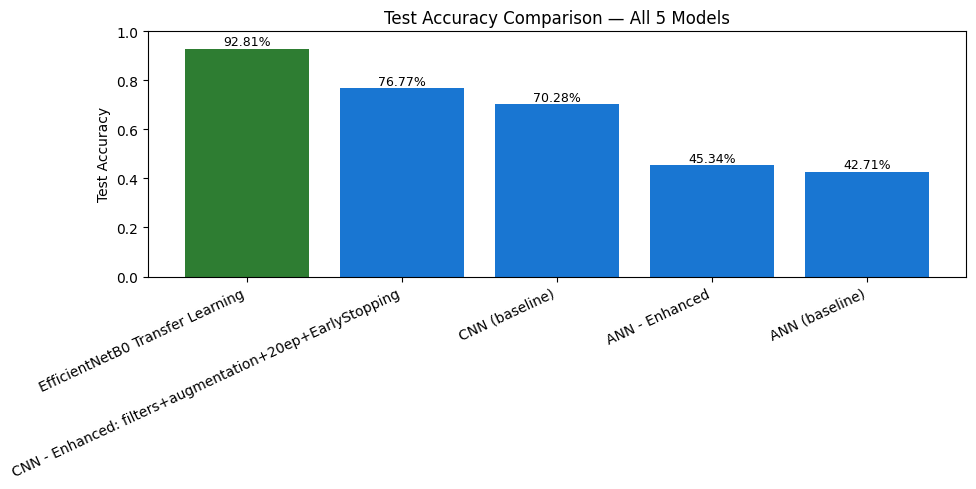

In [35]:
plt.figure(figsize=(10, 5))
bars = plt.bar(comparison_with_bonus["Model"], comparison_with_bonus["Test Accuracy"],
                color=['#2e7d32' if 'EfficientNet' in m else '#1976d2' for m in comparison_with_bonus["Model"]])
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.title("Test Accuracy Comparison — All 5 Models")
plt.xticks(rotation=25, ha='right')
for bar, acc in zip(bars, comparison_with_bonus["Test Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
              f"{acc:.2%}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()


**Observation**
- EfficientNetB0 Transfer Learning achieved the highest test accuracy (92.81%).
- Enhanced CNN (76.77%) performed better than the Baseline CNN (70.28%).
- Both CNN models outperformed the ANN models.
- Baseline ANN achieved the lowest accuracy (42.71%).
- Overall, Transfer Learning with EfficientNetB0 gave the best performance on the CIFAR-10 dataset.

## 13. Performance Metrics Comparison of All Models

This step evaluates and compares the performance of all five models using Accuracy, Precision, Recall, and F1-Score. The classification_report is used to calculate these metrics, and the results are summarized in a table for easy comparison.

In [27]:
from sklearn.metrics import classification_report

def model_metrics(name, y_true, y_pred):
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    return {
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision (macro)": report["macro avg"]["precision"],
        "Recall (macro)": report["macro avg"]["recall"],
        "F1-Score (macro)": report["macro avg"]["f1-score"],
    }
ann_pred          = np.argmax(ann_model.predict(x_test_flat), axis=1)
cnn_pred          = np.argmax(cnn_model.predict(x_test_norm), axis=1)
ann_deep_pred     = np.argmax(ann_deep_model.predict(x_test_flat), axis=1)
enhanced_cnn_pred = np.argmax(enhanced_cnn_model.predict(x_test_norm), axis=1)
effnet_pred = np.argmax(model.predict(test_ds), axis=1)

metrics_summary = pd.DataFrame([
    model_metrics("ANN (baseline)", y_test, ann_pred),
    model_metrics("CNN (baseline)", y_test, cnn_pred),
    model_metrics("ANN - Enhanced", y_test, ann_deep_pred),
    model_metrics("CNN - Enhanced", y_test, enhanced_cnn_pred),
    model_metrics("EfficientNetB0 Transfer Learning", y_test, effnet_pred),
]).sort_values("Accuracy", ascending=False).reset_index(drop=True)

metrics_summary


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


,Model,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
0,EfficientNetB0 Transfer Learning,0.9281,0.927780,0.9281,0.927550
1,CNN - Enhanced,0.7677,0.773124,0.7677,0.767759
2,CNN (baseline),0.7028,0.714056,0.7028,0.699998
3,ANN - Enhanced,0.4534,0.461463,0.4534,0.447228
4,ANN (baseline),0.4271,0.441728,0.4271,0.419761


**Observation**
- EfficientNetB0 Transfer Learning achieved the best performance with 92.81% Accuracy, 92.78% Precision, 92.81% Recall, and 92.76% F1-Score.
- Enhanced CNN performed better than the Baseline CNN across all evaluation metrics.
- CNN models outperformed both ANN models in Accuracy, Precision, Recall, and F1-Score.
- Baseline ANN showed the lowest performance among all models.
- Overall, EfficientNetB0 Transfer Learning is the best model for the CIFAR-10 image classification task.

# 14. Overall Model Performance Comparison

This table compares the training, validation, and testing accuracy and loss of all models. It provides a complete performance summary and helps identify the model that generalizes best on unseen test data.

In [32]:
model_state = pd.DataFrame([
    {
        "Model": "EfficientNetB0 Transfer Learning",
        "Training Accuracy": history_phase2.history['accuracy'][-1],
        "Validation Accuracy": history_phase2.history['val_accuracy'][-1],
        "Testing Accuracy": test_acc,
        "Training Loss": history_phase2.history['loss'][-1],
        "Validation Loss": history_phase2.history['val_loss'][-1],
        "Testing Loss": test_loss,
    },
    {
        "Model": "CNN - Enhanced",
        "Training Accuracy": enhanced_cnn_history.history['accuracy'][-1],
        "Validation Accuracy": enhanced_cnn_history.history['val_accuracy'][-1],
        "Testing Accuracy": enhanced_cnn_test_acc,
        "Training Loss": enhanced_cnn_history.history['loss'][-1],
        "Validation Loss": enhanced_cnn_history.history['val_loss'][-1],
        "Testing Loss": enhanced_cnn_test_loss,
    },
    {
        "Model": "ANN - Enhanced",
        "Training Accuracy": ann_deep_history.history['accuracy'][-1],
        "Validation Accuracy": ann_deep_history.history['val_accuracy'][-1],
        "Testing Accuracy": ann_deep_test_acc,
        "Training Loss": ann_deep_history.history['loss'][-1],
        "Validation Loss": ann_deep_history.history['val_loss'][-1],
        "Testing Loss": ann_deep_test_loss,
    },
    {
        "Model": "CNN (baseline)",
        "Training Accuracy": cnn_history.history['accuracy'][-1],
        "Validation Accuracy": cnn_history.history['val_accuracy'][-1],
        "Testing Accuracy": cnn_test_acc,
        "Training Loss": cnn_history.history['loss'][-1],
        "Validation Loss": cnn_history.history['val_loss'][-1],
        "Testing Loss": cnn_test_loss,
    },
    {
        "Model": "ANN (baseline)",
        "Training Accuracy": ann_history.history['accuracy'][-1],
        "Validation Accuracy": ann_history.history['val_accuracy'][-1],
        "Testing Accuracy": ann_test_acc,
        "Training Loss": ann_history.history['loss'][-1],
        "Validation Loss": ann_history.history['val_loss'][-1],
        "Testing Loss": ann_test_loss,
    }, 
])
model_state.style.set_properties(
    subset=["Testing Accuracy"],
    **{"font-weight": "bold"}
)


,Model,Training Accuracy,Validation Accuracy,Testing Accuracy,Training Loss,Validation Loss,Testing Loss
0,EfficientNetB0 Transfer Learning,0.876489,0.934200,0.928100,1.016420,0.698367,0.708397
1,CNN - Enhanced,0.774511,0.757200,0.767700,0.650273,0.701947,0.682923
2,ANN - Enhanced,0.429578,0.456000,0.453400,1.589841,1.540833,1.509334
3,CNN (baseline),0.843556,0.714600,0.702800,0.439423,0.953369,1.022142
4,ANN (baseline),0.382622,0.423600,0.427100,1.694349,1.652865,1.645283


**Observation**
- EfficientNetB0 Transfer Learning achieved the highest training, validation, and testing accuracy, making it the best-performing model.
- Enhanced CNN performed better than the Baseline CNN, showing improved testing accuracy and lower testing loss.
- Baseline CNN had high training accuracy but lower validation and testing accuracy, indicating overfitting.
- ANN Enhanced performed slightly better than the Baseline ANN, but both achieved lower accuracy than the CNN models.
- Overall, EfficientNetB0 Transfer Learning provided the best generalization and overall performance on the CIFAR-10 dataset.

## 15. Conclusion
- The Baseline ANN achieved the lowest accuracy, showing that it is not well-suited for image classification.
- The CNN models outperformed the ANN models by effectively learning image features.
- The Enhanced CNN improved accuracy through data augmentation, additional layers, and regularization techniques.
- EfficientNetB0 Transfer Learning achieved the highest test accuracy (92.81%) and delivered the best overall performance.
- Overall, the project demonstrates that transfer learning with a pre-trained CNN is the most effective approach for the CIFAR-10 image classification task.